[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OceanNetworksCanada/python-community-notebooks/blob/main/workflows/transit-analysis/grid_transit.ipynb)

In [1]:
!uv pip install -q xarray onc scipy bottleneck

In [2]:
# Bootstrap cell
import sys
from pathlib import Path
import os

def in_colab() -> bool:
    try:
        import google.colab
        return True
    except ImportError:
        return False

def setup_repo_for_shared_imports():
    """
    Locate (or clone, in Colab) the notebook repository and add it to ``sys.path``.

    Notes:
        - In Colab, this ensures the repository exists at
          ``/content/python-community-notebooks`` by cloning it if needed.
        - In local environments, this searches upward from the current working
          directory for ``shared`` to identify the repo root.
        - If a repo root is found, it is prepended to ``sys.path`` to enable
          imports from the repository (e.g., ``shared`` modules).
    """
    repo_dir: Path | None = None

    if in_colab():
        repo_dir = Path('/content/python-community-notebooks')
        if not repo_dir.exists():
            !git clone --depth 1 https://github.com/OceanNetworksCanada/python-community-notebooks.git /content/python-community-notebooks
    else:
        cwd = Path.cwd().resolve()
        for candidate in [cwd, *cwd.parents]:
            if (candidate / 'shared').exists():
                repo_dir = candidate
                break

    if repo_dir is not None and str(repo_dir) not in sys.path:
        sys.path.insert(0, str(repo_dir))



def init_token():   
    """
    Initialize the ONC_TOKEN environment variable.

    Notes:
        - If in Colab, add your ONC_TOKEN secrets by clicking the key icon on the left sidebar
        - If in local, create .env file in the root directory, and add ONC_TOKEN=XXX in your .env file
    """
    if in_colab():
        from google.colab import userdata
        os.environ['ONC_TOKEN'] = userdata.get('ONC_TOKEN')
    else:
        from dotenv import load_dotenv
        load_dotenv()

init_token()
setup_repo_for_shared_imports()

In [3]:
from datetime import datetime, timedelta
import numpy as np
from onc import ONC
import xarray as xr
from xarray.groupers import BinGrouper

from shared.IanTBlack_common import format_datetime, convert_scalar_data, split_periods, identify_transit_ports

In [4]:
onc = ONC()

In [5]:
date_from = datetime(2025,11,3,9,0,0)
date_to = datetime(2025,11,3,20,15,0)

# Download NAV
params = {'locationCode': 'TWDP.N1',
          'deviceCategoryCode': 'NAV',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False}
json_response = onc.getScalardata(filters = params, allPages=True)
nav = convert_scalar_data(json_response_data = json_response, out_as = 'xarray')


# Download TSG
params = {'locationCode': 'TWDP',
          'deviceCategoryCode': 'TSG',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False}
json_response = onc.getScalardata(filters = params, allPages=True)
tsg = convert_scalar_data(json_response_data=json_response, out_as = 'xarray')

In [6]:
ds = xr.combine_by_coords([nav, tsg], combine_attrs = 'drop_conflicts', join = 'outer')

# Linearly interpolate to nearest position. For simplicity, we do not assume a time-lag.
ds['latitude'] = ds['latitude'].interpolate_na(dim = 'time', method = 'linear', max_gap = timedelta(seconds = 5), fill_value = 'extrapolate')
ds['longitude'] = ds['longitude'].interpolate_na(dim = 'time', method = 'linear', max_gap = timedelta(seconds = 5), fill_value = 'extrapolate')

ds = ds.sel(time = tsg.time)  # Select the original TSG timestamps.
ds = ds[['latitude', 'longitude', 'temperature','practical_salinity']]

In [7]:
transit_times = split_periods(ds.time, min_gap = 60*5)
transits = [ds.sel(time = slice(t['dateFrom'], t['dateTo'])) for t in transit_times]

# Apply median filter with a window size of 13 samples to each transit.
transits = [t.rolling({'time': 13}, center = True, min_periods = 1).median() for t in transits]

In [8]:
example_transit = transits[-1]

In [9]:
def grid_transit(transit: xr.Dataset,
                 lat_min: float = None,
                 lat_max: float = None,
                 lon_min: float = None,
                 lon_max: float = None,
                 bin_size: float = 0.005,
                 central_buffer: float = 0.0025) -> xr.Dataset:

    if lat_min is None:
        lat_min = transit.latitude.min().values - (bin_size * 2)
    if lon_min is None:
        lon_min = transit.longitude.min().values - (bin_size * 2)
    if lat_max is None:
        lat_max = transit.latitude.max().values - (bin_size * 2)
    if lon_max is None:
        lon_max = transit.longitude.max().values - (bin_size * 2)

    transit['ftime'] = transit.time.astype(float)
    lat_grouper = BinGrouper(bins=np.arange(lat_min - central_buffer, lat_max + central_buffer, bin_size))
    lon_grouper = BinGrouper(bins=np.arange(lon_min - central_buffer, lon_max + central_buffer, bin_size))

    bin_lats = lat_grouper.bins[:-1] + central_buffer
    bin_lons = lon_grouper.bins[:-1] + central_buffer

    binned_transit = transit.groupby(latitude=lat_grouper,
                                     longitude=lon_grouper).mean(skipna=True)
    binned_transit['latitude'] = (['latitude_bins'], bin_lats)
    binned_transit['longitude'] = (['longitude_bins'], bin_lons)
    binned_transit = binned_transit.swap_dims({'latitude_bins': 'latitude', 'longitude_bins': 'longitude'})
    binned_transit['time'] = binned_transit.ftime.astype('datetime64[ns]')
    binned_transit = binned_transit.drop_vars(['latitude_bins', 'longitude_bins', 'ftime'], errors='ignore')
    binned_transit = binned_transit.dropna(dim='latitude', how='all')
    binned_transit = binned_transit.dropna(dim='longitude', how='all')

    return binned_transit

In [10]:
binned_example = grid_transit(example_transit)

In [11]:
binned_example

<xarray.Dataset> Size: 132kB
Dimensions:             (latitude: 42, longitude: 130)
Coordinates:
  * latitude            (latitude) float64 336B 49.0 49.01 49.01 ... 49.2 49.21
  * longitude           (longitude) float64 1kB -123.9 -123.9 ... -123.2 -123.2
Data variables:
    temperature         (latitude, longitude) float64 44kB nan nan ... nan nan
    practical_salinity  (latitude, longitude) float64 44kB nan nan ... nan nan
    time                (latitude, longitude) datetime64[ns] 44kB NaT ... NaT
Attributes:
    locationName:  Metadata query input set to minimum. | Not Found
    qaqcFlagInfo:  0:No Quality Control\n1:Data Passed All Tests\n2:Data Prob...

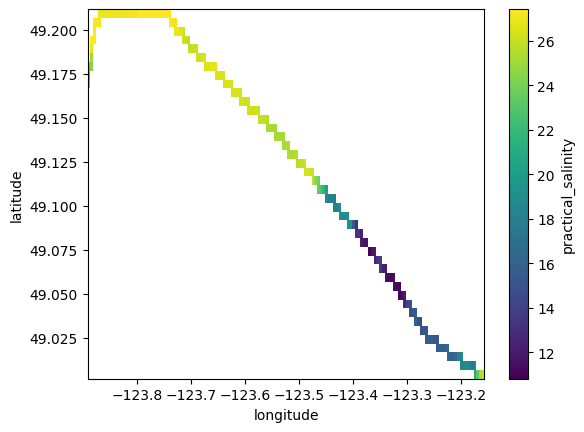

In [12]:
binned_example.practical_salinity.plot()